In [41]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

In [42]:
X.shape

(300, 2)

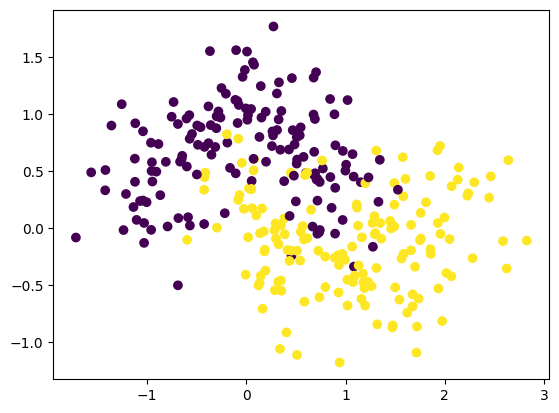

In [43]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)

In [44]:
from sklearn.model_selection import train_test_split
# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
X_train.shape

(240, 2)

In [46]:
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [47]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [49]:
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5000 - loss: 0.6955 - val_accuracy: 0.5833 - val_loss: 0.6720
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5208 - loss: 0.6864 - val_accuracy: 0.6250 - val_loss: 0.6649
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5521 - loss: 0.6781 - val_accuracy: 0.6667 - val_loss: 0.6575
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5365 - loss: 0.6700 - val_accuracy: 0.6667 - val_loss: 0.6500
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5365 - loss: 0.6620 - val_accuracy: 0.7500 - val_loss: 0.6410
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6198 - loss: 0.6532 - val_accuracy: 0.7917 - val_loss: 0.6303
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7135 - loss: 0.6425 - val_accuracy: 0.8542 - val_loss: 0.6188
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7969 - loss: 0.6313 - val_accuracy: 0.8333 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: title={'center': 'Weight_initilization with default'}>

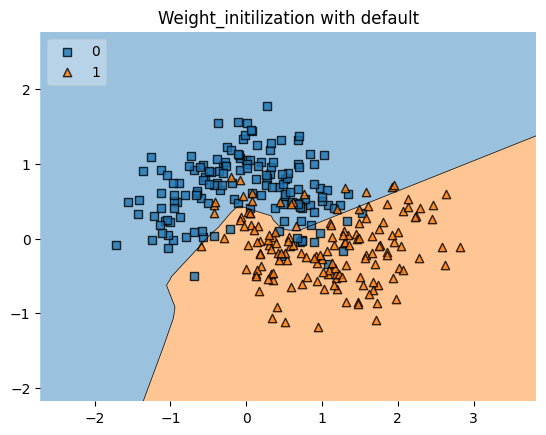

In [ ]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
plt.title('Weight_initilization with default') # Default is Xavier 
plot_decision_regions(X, y, clf=model, legend=2)

In [51]:
y_evaluate = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [52]:
y_pred = (y_evaluate >= 0.5).astype('int')

In [54]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8333333333333334

# Accuracy is 83 %

In [55]:
model_1 = Sequential()

model_1.add(Dense(10,activation='relu',input_dim=2, kernel_initializer='he_normal'))
model_1.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model_1.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model_1.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model_1.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,115 (4.36 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 744 (2.91 KB)

In [56]:
model_1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [57]:
history_wight_normal = model_1.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7396 - loss: 0.6389 - val_accuracy: 0.7292 - val_loss: 0.6308
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7760 - loss: 0.6119 - val_accuracy: 0.7500 - val_loss: 0.6073
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7865 - loss: 0.5903 - val_accuracy: 0.7292 - val_loss: 0.5874
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7917 - loss: 0.5715 - val_accuracy: 0.7500 - val_loss: 0.5697
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8125 - loss: 0.5540 - val_accuracy: 0.7917 - val_loss: 0.5524
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8333 - loss: 0.5343 - val_accuracy: 0.8125 - val_loss: 0.5348
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8594 - loss: 0.5159 - val_accuracy: 0.8542 - val_loss: 0.5168
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8594 - loss: 0.4961 - val_accuracy: 0.8958 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: title={'center': 'Weight_init_with_"he_normal" on ReLu'}>

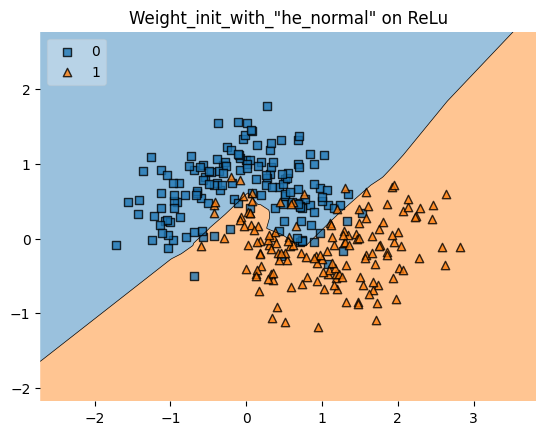

In [68]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
plt.title('Weight_init_with_"he_normal" on ReLu')
plot_decision_regions(X, y, clf=model_1, legend=2)

In [59]:
y_eval = model_1.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [60]:
y_pred_1 = (y_eval >= 0.5 ).astype('int')
accuracy_score(y_test,y_pred_1)

0.9

# Accuracy is 90 %

In [61]:
model_2 = Sequential()

model_2.add(Dense(10,activation='relu',input_dim=2, kernel_initializer='he_uniform'))
model_2.add(Dense(10,activation='relu',kernel_initializer='he_uniform'))
model_2.add(Dense(10,activation='relu',kernel_initializer='he_uniform'))
model_2.add(Dense(10,activation='relu',kernel_initializer='he_uniform'))
model_2.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,115 (4.36 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 744 (2.91 KB)

In [62]:
model_2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [73]:
history_weight_uniform = model_2.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9427 - loss: 0.1323 - val_accuracy: 0.8333 - val_loss: 0.4629
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9375 - loss: 0.1329 - val_accuracy: 0.8542 - val_loss: 0.4554
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9427 - loss: 0.1328 - val_accuracy: 0.8542 - val_loss: 0.4594
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9427 - loss: 0.1309 - val_accuracy: 0.8333 - val_loss: 0.4652
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9427 - loss: 0.1331 - val_accuracy: 0.8542 - val_loss: 0.4646
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9479 - loss: 0.1317 - val_accuracy: 0.8542 - val_loss: 0.4603
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9427 - loss: 0.1345 - val_accuracy: 0.8958 - val_loss: 0.4519
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9427 - loss: 0.1337 - val_accuracy: 0.8333 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: title={'center': 'Weight_init_with_"he_uniform" on ReLu'}>

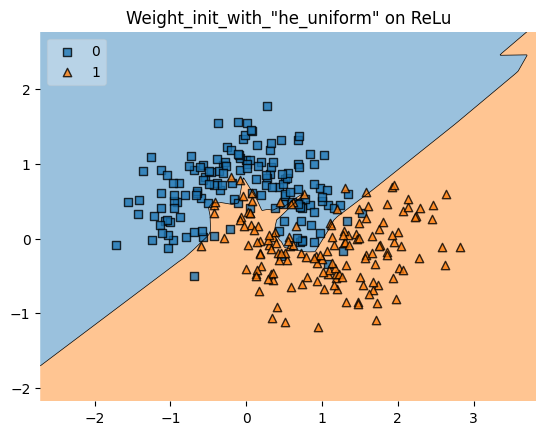

In [74]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
plt.title('Weight_init_with_"he_uniform" on ReLu')
plot_decision_regions(X, y, clf=model_2, legend=2)

In [75]:
y_ev = model_2.predict(X_test)
y_pred_2 = (y_ev >= 0.5 )
accuracy_score(y_test,y_pred_2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


0.85

# Accuracy is 83 %